In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Cargar datos limpios
df_anual = pd.read_csv('data/cobre_anual_limpio.csv', sep=';', decimal=',')
df_mensual = pd.read_csv('data/cobre_mensual_limpio.csv', sep=';', decimal=',')
df_mensual['Fecha'] = pd.to_datetime(df_mensual['Fecha'])

print("Anual:", df_anual.shape)
print("Mensual:", df_mensual.shape)

Anual: (35, 6)
Mensual: (420, 7)


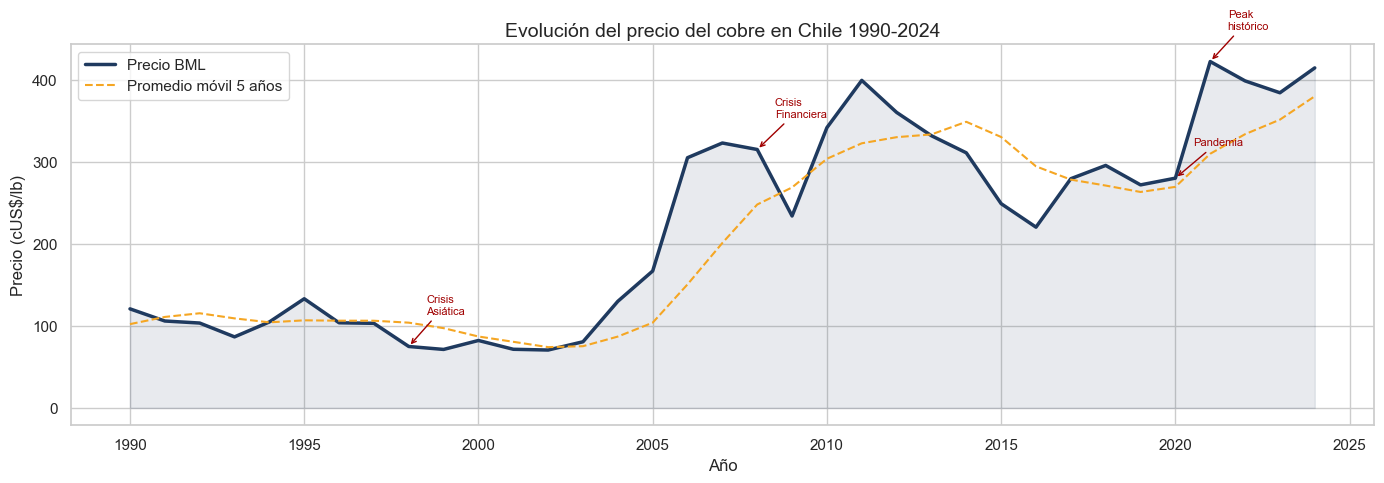

In [3]:
# Gráfico 1: Evolución histórica con eventos clave
fig, ax = plt.subplots()

ax.plot(df_anual['Año'], df_anual['Precio_BML'], color='#1F3A5F', linewidth=2.5, label='Precio BML')
ax.plot(df_anual['Año'], df_anual['Promedio_Movil_5'], color='#F5A623', linewidth=1.5, linestyle='--', label='Promedio móvil 5 años')
ax.fill_between(df_anual['Año'], df_anual['Precio_BML'], alpha=0.1, color='#1F3A5F')

# Marcar eventos clave
eventos = {
    1998: 'Crisis\nAsiática',
    2008: 'Crisis\nFinanciera',
    2020: 'Pandemia',
    2021: 'Peak\nhistórico'
}
for año, texto in eventos.items():
    precio = df_anual[df_anual['Año'] == año]['Precio_BML'].values[0]
    ax.annotate(texto, xy=(año, precio), xytext=(año+0.5, precio+40),
                fontsize=8, color='#A00000',
                arrowprops=dict(arrowstyle='->', color='#A00000', lw=1))

ax.set_title('Evolución del precio del cobre en Chile 1990-2024', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Precio (cUS$/lb)')
ax.legend()

plt.tight_layout()
plt.savefig('graficos/01_evolucion_precio.png', dpi=150, bbox_inches='tight')
plt.show()

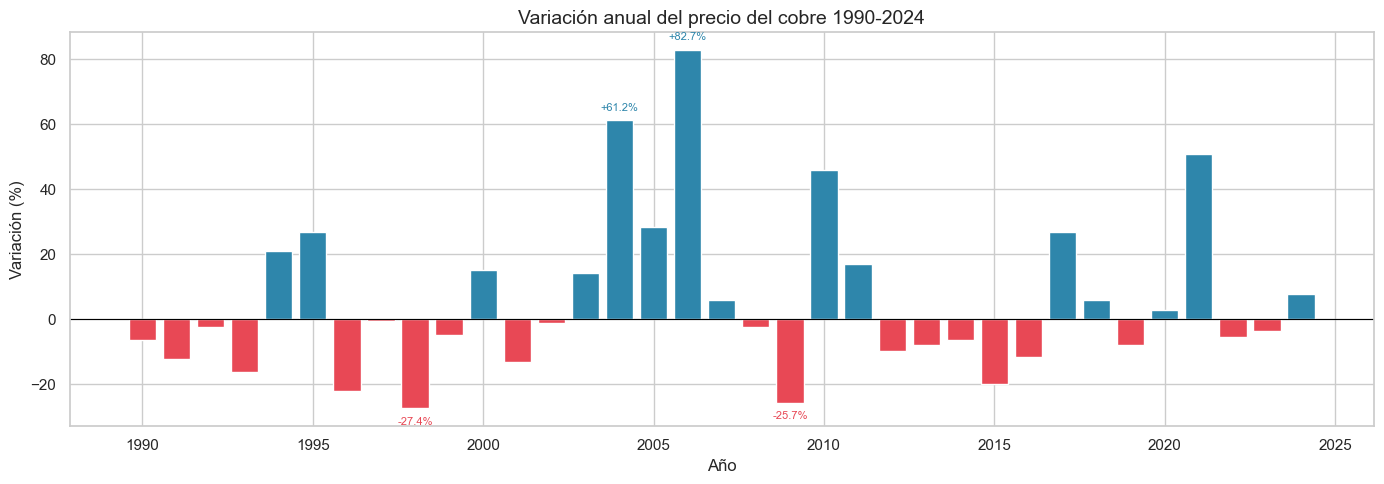

In [4]:
# Gráfico 2: Variación anual del precio
fig, ax = plt.subplots()

colores = ['#2E86AB' if v >= 0 else '#E84855' for v in df_anual['Variacion_Anual_%']]
ax.bar(df_anual['Año'], df_anual['Variacion_Anual_%'], color=colores, width=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Variación anual del precio del cobre 1990-2024', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Variación (%)')

# Anotar los años más extremos
for _, row in df_anual.nlargest(2, 'Variacion_Anual_%').iterrows():
    ax.annotate(f"+{row['Variacion_Anual_%']:.1f}%", 
                xy=(row['Año'], row['Variacion_Anual_%']),
                xytext=(row['Año'], row['Variacion_Anual_%']+3),
                fontsize=8, ha='center', color='#2E86AB')

for _, row in df_anual.nsmallest(2, 'Variacion_Anual_%').iterrows():
    ax.annotate(f"{row['Variacion_Anual_%']:.1f}%",
                xy=(row['Año'], row['Variacion_Anual_%']),
                xytext=(row['Año'], row['Variacion_Anual_%']-5),
                fontsize=8, ha='center', color='#E84855')

plt.tight_layout()
plt.savefig('graficos/02_variacion_anual.png', dpi=150, bbox_inches='tight')
plt.show()

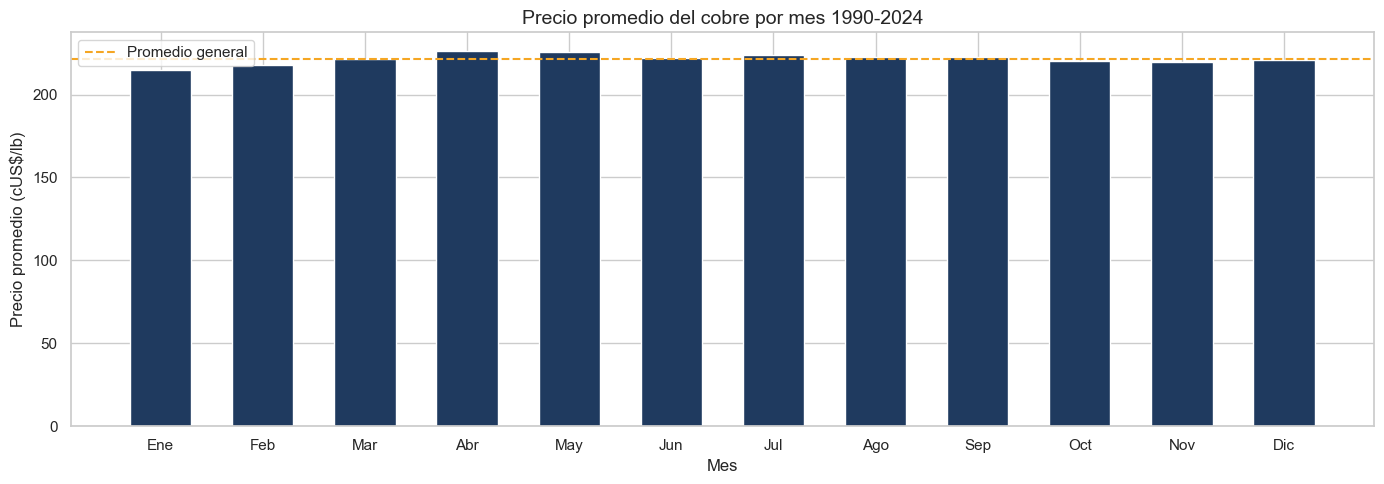

   Mes_Nombre  Precio_BML
0         Ene      214.82
1         Feb      217.61
2         Mar      221.48
3         Abr      226.23
4         May      225.72
5         Jun      221.89
6         Jul      223.77
7         Ago      222.96
8         Sep      222.95
9         Oct      220.44
10        Nov      219.47
11        Dic      220.99


In [5]:
# Gráfico 3: Estacionalidad mensual del precio
meses_nombre = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
                7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

estacionalidad = df_mensual.groupby('Mes')['Precio_BML'].mean().reset_index()
estacionalidad['Mes_Nombre'] = estacionalidad['Mes'].map(meses_nombre)

fig, ax = plt.subplots()
ax.bar(estacionalidad['Mes_Nombre'], estacionalidad['Precio_BML'], 
       color='#1F3A5F', width=0.6)
ax.axhline(y=estacionalidad['Precio_BML'].mean(), color='#F5A623', 
           linewidth=1.5, linestyle='--', label='Promedio general')
ax.set_title('Precio promedio del cobre por mes 1990-2024', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Precio promedio (cUS$/lb)')
ax.legend()

plt.tight_layout()
plt.savefig('graficos/03_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()

print(estacionalidad[['Mes_Nombre', 'Precio_BML']].round(2))

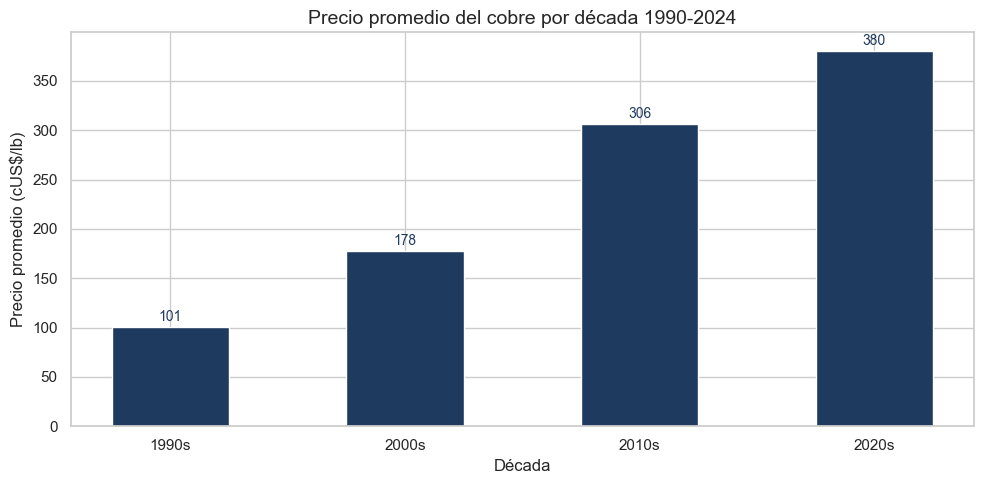

In [6]:
# Gráfico 4: Precio promedio por década
decadas = df_anual.groupby('Década')['Precio_BML'].mean().reset_index()
decadas['Década'] = decadas['Década'].astype(str) + 's'

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(decadas['Década'], decadas['Precio_BML'], color='#1F3A5F', width=0.5)

# Agregar valores encima de cada barra
for bar, val in zip(bars, decadas['Precio_BML']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, color='#1F3A5F')

ax.set_title('Precio promedio del cobre por década 1990-2024', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Precio promedio (cUS$/lb)')

plt.tight_layout()
plt.savefig('graficos/04_decadas.png', dpi=150, bbox_inches='tight')
plt.show()